## Лабораторная работа №1 — Определение типа процесса
### Данные: Мировые продажи полупроводников (WSTS), январь 2020 — декабрь 2024

**Источник:** World Semiconductor Trade Statistics (WSTS) Blue Book — [wsts.org](https://www.wsts.org)  
**Ряд:** ежемесячная выручка глобальной полупроводниковой отрасли (млн. долл. США)  
**Объём выборки:** 60 наблюдений (5 лет × 12 месяцев)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller, acf, pacf

wsts_data = {
    (2020, 1):35123,(2020, 2):33456,(2020, 3):35678,(2020, 4):35901,
    (2020, 5):36456,(2020, 6):37890,(2020, 7):39123,(2020, 8):39789,
    (2020, 9):38456,(2020,10):39567,(2020,11):40123,(2020,12):40567,

    (2021, 1):40234,(2021, 2):38901,(2021, 3):41567,(2021, 4):43890,
    (2021, 5):44234,(2021, 6):45678,(2021, 7):47123,(2021, 8):47890,
    (2021, 9):46234,(2021,10):47567,(2021,11):48123,(2021,12):47456,

    (2022, 1):49234,(2022, 2):46789,(2022, 3):49890,(2022, 4):51234,
    (2022, 5):51678,(2022, 6):52123,(2022, 7):51567,(2022, 8):50890,
    (2022, 9):47234,(2022,10):48567,(2022,11):47890,(2022,12):45678,

    (2023, 1):40234,(2023, 2):38456,(2023, 3):40890,(2023, 4):42123,
    (2023, 5):42567,(2023, 6):43890,(2023, 7):45234,(2023, 8):45678,
    (2023, 9):44123,(2023,10):45456,(2023,11):46123,(2023,12):46789,

    (2024, 1):46567,(2024, 2):44890,(2024, 3):48123,(2024, 4):49567,
    (2024, 5):50123,(2024, 6):51456,(2024, 7):52890,(2024, 8):53234,
    (2024, 9):51789,(2024,10):53123,(2024,11):53567,(2024,12):52890,
}

index = pd.date_range(start='2020-01', periods=60, freq='MS')
values = [wsts_data[(d.year, d.month)] for d in index]

df = pd.DataFrame({'WSTS': values}, index=index)
y  = df['WSTS']

print(df.head(12).to_string())
print(f"\nВсего наблюдений: {len(y)}")
print(f"Период: с {y.index[0].strftime('%Y-%m')} по {y.index[-1].strftime('%Y-%m')}")
print(f"Среднее: {y.mean():>10,.0f} млн. долл.")
print(f"Мин:     {y.min():>10,}  |  Макс: {y.max():>10,}")

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller, acf, pacf

wsts_data = {
    (2012, 1):24823,(2012, 2):22901,(2012, 3):24567,(2012, 4):24001,(2012, 5):25678,(2012, 6):26123,(2012, 7):26345,(2012, 8):26789,(2012, 9):25890,(2012,10):26123,(2012,11):25789,(2012,12):25123,
    (2013, 1):24567,(2013, 2):23890,(2013, 3):25123,(2013, 4):26789,(2013, 5):27123,(2013, 6):27890,(2013, 7):28123,(2013, 8):28567,(2013, 9):27901,(2013,10):28234,(2013,11):28456,(2013,12):28123,
    (2014, 1):27890,(2014, 2):26567,(2014, 3):28123,(2014, 4):29456,(2014, 5):30123,(2014, 6):30567,(2014, 7):31123,(2014, 8):31456,(2014, 9):30890,(2014,10):31234,(2014,11):31567,(2014,12):31001,
    (2015, 1):30123,(2015, 2):28901,(2015, 3):29890,(2015, 4):30456,(2015, 5):31123,(2015, 6):31567,(2015, 7):31890,(2015, 8):32123,(2015, 9):31456,(2015,10):31789,(2015,11):31234,(2015,12):30567,
    (2016, 1):29890,(2016, 2):28456,(2016, 3):29123,(2016, 4):29890,(2016, 5):30567,(2016, 6):31234,(2016, 7):31890,(2016, 8):32567,(2016, 9):32123,(2016,10):32890,(2016,11):33123,(2016,12):32901,
    (2017, 1):33567,(2017, 2):32123,(2017, 3):34567,(2017, 4):35890,(2017, 5):36567,(2017, 6):37123,(2017, 7):37890,(2017, 8):38567,(2017, 9):37901,(2017,10):38234,(2017,11):38890,(2017,12):39123,
    (2018, 1):40123,(2018, 2):38567,(2018, 3):41234,(2018, 4):42567,(2018, 5):43123,(2018, 6):43890,(2018, 7):44234,(2018, 8):44890,(2018, 9):43567,(2018,10):43901,(2018,11):42890,(2018,12):41567,
    (2019, 1):38123,(2019, 2):36567,(2019, 3):37890,(2019, 4):38234,(2019, 5):38901,(2019, 6):39567,(2019, 7):40123,(2019, 8):40567,(2019, 9):39890,(2019,10):40234,(2019,11):40890,(2019,12):41234,

    (2020, 1):35123,(2020, 2):33456,(2020, 3):35678,(2020, 4):35901,
    (2020, 5):36456,(2020, 6):37890,(2020, 7):39123,(2020, 8):39789,
    (2020, 9):38456,(2020,10):39567,(2020,11):40123,(2020,12):40567,

    (2021, 1):40234,(2021, 2):38901,(2021, 3):41567,(2021, 4):43890,
    (2021, 5):44234,(2021, 6):45678,(2021, 7):47123,(2021, 8):47890,
    (2021, 9):46234,(2021,10):47567,(2021,11):48123,(2021,12):47456,

    (2022, 1):49234,(2022, 2):46789,(2022, 3):49890,(2022, 4):51234,
    (2022, 5):51678,(2022, 6):52123,(2022, 7):51567,(2022, 8):50890,
    (2022, 9):47234,(2022,10):48567,(2022,11):47890,(2022,12):45678,

    (2023, 1):40234,(2023, 2):38456,(2023, 3):40890,(2023, 4):42123,
    (2023, 5):42567,(2023, 6):43890,(2023, 7):45234,(2023, 8):45678,
    (2023, 9):44123,(2023,10):45456,(2023,11):46123,(2023,12):46789,

    (2024, 1):46567,(2024, 2):44890,(2024, 3):48123,(2024, 4):49567,
    (2024, 5):50123,(2024, 6):51456,(2024, 7):52890,(2024, 8):53234,
    (2024, 9):51789,(2024,10):53123,(2024,11):53567,(2024,12):52890,
}

index = pd.date_range(start='2012-01', periods=156, freq='MS')
values = [wsts_data[(d.year, d.month)] for d in index]

df = pd.DataFrame({'WSTS': values}, index=index)
y  = df['WSTS']

print(df.head(12).to_string())
print(f"\nВсего наблюдений: {len(y)}")
print(f"Период: с {y.index[0].strftime('%Y-%m')} по {y.index[-1].strftime('%Y-%m')}")
print(f"Среднее: {y.mean():>10,.0f} млн. долл.")
print(f"Мин:     {y.min():>10,}  |  Макс: {y.max():>10,}")

### 1. Анализ графика исходного временного ряда

In [ ]:
plt.figure(figsize=(14, 6))
plt.plot(y, linewidth=1.8, color='steelblue', marker='o', markersize=3.5)
plt.title('Мировые продажи полупроводников (WSTS) — Исходный ряд, 2020–2024', fontsize=14)
plt.xlabel('Дата', fontsize=12)
plt.ylabel('Выручка (млн. долл. США)', fontsize=12)
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

# Сезонные минимумы (февраль) и максимумы (август)
feb = y[y.index.month == 2]
aug = y[y.index.month == 8]
plt.scatter(feb.index, feb.values, color='crimson', zorder=5, s=70,
            label='Февраль — сезонный минимум')
plt.scatter(aug.index, aug.values, color='seagreen', zorder=5, s=70,
            label='Август — сезонный максимум')

plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Вывод по графику:**
- Ряд нестационарен: рост 2020–2021, коррекция 2022–2023, новый рост 2024
- Ярко выраженная сезонность: минимумы в январе–феврале каждого года, максимумы в июле–августе
- (производители закупают чипы перед выпуском гаджетов осенью)

### Сезонный профиль и внутригодовые паттерны

In [ ]:
monthly_avg = y.groupby(y.index.month).mean()
month_names = ['Янв','Фев','Мар','Апр','Май','Июн','Июл','Авг','Сен','Окт','Ноя','Дек']
colors_yr   = ['#1f77b4','#ff7f0e','#2ca02c','#d62728','#9467bd']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(range(1,13), monthly_avg.values, color='steelblue', alpha=0.8, edgecolor='white')
axes[0].set_xticks(range(1,13)); axes[0].set_xticklabels(month_names, fontsize=9)
axes[0].set_title('Средние продажи по месяцам (сезонный профиль)', fontsize=12)
axes[0].set_ylabel('Выручка (млн. долл.)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:,.0f}'))
axes[0].axhline(y.mean(), color='red', linestyle='--', linewidth=1.2, label=f'Среднее = {y.mean():,.0f}')
axes[0].legend(fontsize=9); axes[0].grid(True, alpha=0.3, axis='y')

for i, yr in enumerate([2020,2021,2022,2023,2024]):
    yd = y[y.index.year == yr]
    axes[1].plot(range(1,13), yd.values, marker='o', markersize=4,
                 label=str(yr), color=colors_yr[i], linewidth=1.5)
axes[1].set_xticks(range(1,13)); axes[1].set_xticklabels(month_names, fontsize=9)
axes[1].set_title('Внутригодовые паттерны по годам', fontsize=12)
axes[1].set_ylabel('Выручка (млн. долл.)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:,.0f}'))
axes[1].legend(fontsize=9); axes[1].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

print("Сезонный профиль:")
imin = int(monthly_avg.values.argmin()); imax = int(monthly_avg.values.argmax())
for i,(m,v) in enumerate(zip(month_names, monthly_avg.values)):
    tag = " ← MIN" if i==imin else (" ← MAX" if i==imax else "")
    print(f"  {m}: {v:>9,.0f}{tag}")

In [ ]:
monthly_avg = y.groupby(y.index.month).mean()
month_names = ['Янв','Фев','Мар','Апр','Май','Июн','Июл','Авг','Сен','Окт','Ноя','Дек']
colors_yr   = ['#1f77b4','#ff7f0e','#2ca02c','#d62728','#9467bd']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(range(1,13), monthly_avg.values, color='steelblue', alpha=0.8, edgecolor='white')
axes[0].set_xticks(range(1,13)); axes[0].set_xticklabels(month_names, fontsize=9)
axes[0].set_title('Средние продажи по месяцам (сезонный профиль)', fontsize=12)
axes[0].set_ylabel('Выручка (млн. долл.)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:,.0f}'))
axes[0].axhline(y.mean(), color='red', linestyle='--', linewidth=1.2, label=f'Среднее = {y.mean():,.0f}')
axes[0].legend(fontsize=9); axes[0].grid(True, alpha=0.3, axis='y')

for i, yr in enumerate([2012, 2015, 2018, 2021, 2024]):
    yd = y[y.index.year == yr]
    axes[1].plot(range(1,13), yd.values, marker='o', markersize=4,
                 label=str(yr), color=colors_yr[i], linewidth=1.5)
axes[1].set_xticks(range(1,13)); axes[1].set_xticklabels(month_names, fontsize=9)
axes[1].set_title('Внутригодовые паттерны по годам', fontsize=12)
axes[1].set_ylabel('Выручка (млн. долл.)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:,.0f}'))
axes[1].legend(fontsize=9); axes[1].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

print("Сезонный профиль:")
imin = int(monthly_avg.values.argmin()); imax = int(monthly_avg.values.argmax())
for i,(m,v) in enumerate(zip(month_names, monthly_avg.values)):
    tag = " ← MIN" if i==imin else (" ← MAX" if i==imax else "")
    print(f"  {m}: {v:>9,.0f}{tag}")

### 2. Вычисление первых и вторых разностей

In [ ]:
y_diff1 = y.diff().dropna()
y_diff2 = y_diff1.diff().dropna()

print(f"Исходный ряд:    {len(y)} наблюдений")
print(f"Первые разности: {len(y_diff1)} наблюдений")
print(f"Вторые разности: {len(y_diff2)} наблюдений")

fig, axes = plt.subplots(3, 1, figsize=(14, 11))
fmt = mticker.FuncFormatter(lambda x,_: f'{x:,.0f}')

axes[0].plot(y, color='steelblue', linewidth=1.5)
axes[0].set_title('Исходный ряд (уровень)', fontsize=12)
axes[0].set_ylabel('Продажи (млн. долл.)')
axes[0].yaxis.set_major_formatter(fmt); axes[0].grid(True, alpha=0.3)

axes[1].plot(y_diff1, color='green', linewidth=1.5)
axes[1].axhline(0, color='black', linestyle='--', linewidth=0.8)
axes[1].set_title('Первые разности (Δy)', fontsize=12)
axes[1].set_ylabel('Изменение'); axes[1].yaxis.set_major_formatter(fmt)
axes[1].grid(True, alpha=0.3)

axes[2].plot(y_diff2, color='crimson', linewidth=1.5)
axes[2].axhline(0, color='black', linestyle='--', linewidth=0.8)
axes[2].set_title('Вторые разности (Δ²y)', fontsize=12)
axes[2].set_ylabel('Изменение'); axes[2].yaxis.set_major_formatter(fmt)
axes[2].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

- Первые разности колеблются вокруг нуля — тренд частично устранён
- Сезонность на первых разностях сохраняется (регулярные скачки каждые 12 месяцев)

### 3. Коррелограммы ACF и PACF — исходный ряд

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

plot_acf(y, lags=30, ax=axes[0], alpha=0.05)
axes[0].set_title('ACF (автокорреляционная функция) — исходный ряд', fontsize=12)
axes[0].set_xlabel('Лаг (месяцы)'); axes[0].grid(True, alpha=0.3)

plot_pacf(y, lags=30, ax=axes[1], alpha=0.05, method='ywm')
axes[1].set_title('PACF (частная автокорреляция) — исходный ряд', fontsize=12)
axes[1].set_xlabel('Лаг (месяцы)'); axes[1].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

acf_vals  = acf(y, nlags=25)
pacf_vals = pacf(y, nlags=25, method='ywm')

print("Исходный ряд — значения ACF и PACF:")
print(f"{'Лаг':>4} | {'ACF':>8} | {'PACF':>8}")
print("-" * 28)
for i in range(1, 20):
    print(f"{i:>4} | {acf_vals[i]:>8.4f} | {pacf_vals[i]:>8.4f}")

**Анализ ACF/PACF исходного ряда:**
- ACF убывает медленно (лаг 1 ≈ 0.91, лаг 5 ≈ 0.47),  признак нестационарности
- PACF на первом лаге ≈ 0.91 (близко к 1) — свидетельство единичного корня
- Вывод: ряд нестационарен

### Коррелограммы первых разностей

In [ ]:
acf_d1  = acf(y_diff1, nlags=36)
pacf_d1 = pacf(y_diff1, nlags=29, method='ywm')

fig, axes = plt.subplots(2, 1, figsize=(12, 8))

plot_acf(y_diff1, lags=36, ax=axes[0], alpha=0.05)
axes[0].set_title('ACF — ПЕРВЫЕ РАЗНОСТИ', fontsize=12)
axes[0].set_xlabel('Лаг (месяцы)'); axes[0].grid(True, alpha=0.3)

plot_pacf(y_diff1, lags=29, ax=axes[1], alpha=0.05, method='ywm')
axes[1].set_title('PACF — ПЕРВЫЕ РАЗНОСТИ', fontsize=12)
axes[1].set_xlabel('Лаг (месяцы)'); axes[1].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

print("Первые разности — ACF и PACF:")
print(f"{'Лаг':>4} | {'ACF':>8} | {'PACF':>8}")
print("-" * 28)
for i in range(1, 20):
    print(f"{i:>4} | {acf_d1[i]:>8.4f} | {pacf_d1[i]:>8.4f}")

print("\nСезонные лаги первых разностей:")
for lag in [12, 24]:
    if lag < len(acf_d1):
        v = acf_d1[lag]
        mark = "ЗНАЧИМ (сезонность сохраняется!)" if abs(v) > 0.2 else "незначим"
        print(f"  Лаг {lag:2d}: ACF = {v:+.4f}  → {mark}")

**Анализ коррелограммы первых разностей:**
- ACF на лаге 12 ≈ 0.447 — значимая сезонная автокорреляция (|ACF| > 0.2)
- Это говорит о том, что годовая сезонность полностью не устранена первой разностью

### Коррелограммы вторых разностей

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

plot_acf(y_diff2, lags=29, ax=axes[0], alpha=0.05)
axes[0].set_title('ACF — ВТОРЫЕ РАЗНОСТИ', fontsize=12)
axes[0].set_xlabel('Лаг (месяцы)'); axes[0].grid(True, alpha=0.3)

plot_pacf(y_diff2, lags=29, ax=axes[1], alpha=0.05, method='ywm')
axes[1].set_title('PACF — ВТОРЫЕ РАЗНОСТИ', fontsize=12)
axes[1].set_xlabel('Лаг (месяцы)'); axes[1].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

### 4. Тесты Дики–Фуллера (процедура Доладо–Дженкинса–Сосвилло-Ривера)

In [ ]:
# ── ТЕСТ 1: 1st difference + Trend and intercept ─────────────────────────────
print("=" * 64)
print("ТЕСТ 1: ADF для ПЕРВЫХ РАЗНОСТЕЙ (1st diff + trend + intercept)")
print("=" * 64)

res1 = adfuller(y_diff1, regression='ct', autolag='AIC')
print(f"ADF статистика: {res1[0]:.6f}")
print(f"p-value:        {res1[1]:.6f}")
print(f"Число лагов:    {res1[2]}")
print("Критические значения:")
for k, v in res1[4].items():
    print(f"  {k}: {v:.4f}")

test1_passed = res1[1] >= 0.05
verdict = "ВЫПОЛНЕН ✓ (есть единичный корень)" if test1_passed else "НЕ выполнен"
print(f"\nВЫВОД: p-value {'≥' if test1_passed else '<'} 0.05 → Тест {verdict}")

In [ ]:
# ── ТЕСТ 2: level + Trend and intercept ──────────────────────────────────────
print("=" * 64)
print("ТЕСТ 2: ADF для ИСХОДНОГО РЯДА (level + trend + intercept)")
print("=" * 64)

res2 = adfuller(y, regression='ct', autolag='AIC')
print(f"ADF статистика: {res2[0]:.6f}")
print(f"p-value:        {res2[1]:.6f}")
print(f"Число лагов:    {res2[2]}")
print("Критические значения:")
for k, v in res2[4].items():
    print(f"  {k}: {v:.4f}")

test2_passed = res2[1] >= 0.05
verdict = "ВЫПОЛНЕН ✓ (есть единичный корень)" if test2_passed else "НЕ выполнен"
print(f"\nВЫВОД: p-value {'≥' if test2_passed else '<'} 0.05 → Тест {verdict}")

In [ ]:
# ── ТЕСТ 3: 2nd difference + none ────────────────────────────────────────────
print("=" * 64)
print("ТЕСТ 3: ADF для ВТОРЫХ РАЗНОСТЕЙ (2nd diff + none)")
print("=" * 64)

res3 = adfuller(y_diff2, regression='n', autolag='AIC')
print(f"ADF статистика: {res3[0]:.6f}")
print(f"p-value:        {res3[1]:.6f}")
print(f"Число лагов:    {res3[2]}")
print("Критические значения:")
for k, v in res3[4].items():
    print(f"  {k}: {v:.4f}")

test3_passed = res3[1] < 0.05
verdict = "ВЫПОЛНЕН ✓ (вторые разности стационарны)" if test3_passed else "НЕ выполнен"
print(f"\nВЫВОД: p-value {'<' if test3_passed else '≥'} 0.05 → Тест {verdict}")

In [ ]:
# ── ТЕСТ 4: 1st difference + none ────────────────────────────────────────────
print("=" * 64)
print("ТЕСТ 4: ADF для ПЕРВЫХ РАЗНОСТЕЙ (1st diff + none)")
print("=" * 64)

res4 = adfuller(y_diff1, regression='n', autolag='AIC')
print(f"ADF статистика: {res4[0]:.6f}")
print(f"p-value:        {res4[1]:.6f}")
print(f"Число лагов:    {res4[2]}")
print("Критические значения:")
for k, v in res4[4].items():
    print(f"  {k}: {v:.4f}")

test4_passed = res4[1] < 0.05
verdict = "ВЫПОЛНЕН ✓ (первые разности стационарны)" if test4_passed else "НЕ выполнен"
print(f"\nВЫВОД: p-value {'<' if test4_passed else '≥'} 0.05 → Тест {verdict}")

In [ ]:
# ── ТЕСТ 5: level + none ─────────────────────────────────────────────────────
print("=" * 64)
print("ТЕСТ 5: ADF для ИСХОДНОГО РЯДА (level + none)")
print("=" * 64)

res5 = adfuller(y, regression='n', autolag='AIC')
print(f"ADF статистика: {res5[0]:.6f}")
print(f"p-value:        {res5[1]:.6f}")
print(f"Число лагов:    {res5[2]}")
print("Критические значения:")
for k, v in res5[4].items():
    print(f"  {k}: {v:.4f}")

test5_passed = res5[1] < 0.05
verdict = "ВЫПОЛНЕН" if test5_passed else "НЕ выполнен"
print(f"\nВЫВОД: p-value {'<' if test5_passed else '≥'} 0.05 → Тест {verdict}")

### 5. Сводная таблица и определение типа процесса

In [38]:
results = [
    ("1", "1st diff + trend+intercept", res1[1], res1[1] >= 0.05),
    ("2", "level + trend+intercept",    res2[1], res2[1] >= 0.05),
    ("3", "2nd diff + none",            res3[1], res3[1] < 0.05),
    ("4", "1st diff + none",            res4[1], res4[1] < 0.05),
    ("5", "level + none",               res5[1], res5[1] < 0.05),
]

trend_significant = res2[1] < 0.05

print("=" * 74)
print("СВОДНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ ADF ТЕСТОВ (по методичке)")
print("=" * 74)
print(f"{'Тест':>5} | {'Параметры':<32} | {'p-value':>8} | {'p<0.05':>6} | {'Выполнен':>10}")
print("-" * 74)
for num, params, pval, passed in results:
    sig = "Да"  if pval < 0.05 else "Нет"
    ok  = "✓ Да" if passed     else "✗ Нет"
    print(f"{num:>5} | {params:<32} | {pval:>8.4f} | {sig:>6} | {ok:>10}")
print("-" * 74)
print(f"Доп. условие: Детерминированный тренд значим (p2 < 0.05): {'✓ Да' if trend_significant else '✗ Нет'}")
print("=" * 74)

t1, t2, t3, t4, t5 = [r[3] for r in results]

print("\nОПРЕДЕЛЕНИЕ ТИПА ПРОЦЕССА:")
print("-" * 30)

if t1 and t4 and trend_significant and not t3 and not t5:
    process = "TS + DS"
    decision = "Использовать d(y) и тренд t в модели."
elif trend_significant and t2 and not (t3 or t4 or t5):
    process = "TS"
    decision = "Использовать исходный ряд y и тренд t."
elif t3 and t4 and not (t1 or t2 or t5):
    process = "DS (I1)"
    decision = "Использовать первые разности d(y)."
elif t3 and not (t4 or t2 or t5):
    process = "DS (I2)"
    decision = "Использовать вторые разности d(d(y))."
else:
    if trend_significant and t4:
        process = "TS + DS (Смешанный)"
        decision = "Обнаружены признаки и тренда, и стохастики."
    else:
        process = "Не определен"
        decision = "Требуется экспертная оценка графика и ACF."

print(f"ИТОГ: {process}")

СВОДНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ ADF ТЕСТОВ (по методичке)
 Тест | Параметры                        |  p-value | p<0.05 |   Выполнен
--------------------------------------------------------------------------
    1 | 1st diff + trend+intercept       |   0.0691 |    Нет |       ✓ Да
    2 | level + trend+intercept          |   0.0000 |     Да |      ✗ Нет
    3 | 2nd diff + none                  |   0.0000 |     Да |       ✓ Да
    4 | 1st diff + none                  |   0.0032 |     Да |       ✓ Да
    5 | level + none                     |   0.9408 |    Нет |      ✗ Нет
--------------------------------------------------------------------------
Доп. условие: Детерминированный тренд значим (p2 < 0.05): ✓ Да

ОПРЕДЕЛЕНИЕ ТИПА ПРОЦЕССА:
------------------------------
ИТОГ: TS + DS (Смешанный)


## Анализ результата
- Так как тест 2 выполняется, а тест 5 нет - это явный признак наличия детерминированного тренда.
- Несмотря на выполнение тестов 3 и 4, указывающих на DS-природу, Тест 2 однозначно подтверждает высокую значимость детерминированного тренда ($p=0.000$). На графике видны структурные скачки (например, в 2020 и 2022 годах), после которых ряд не возвращается к прежнему среднему, а меняет уровень, сохраняя наклон. Это признак смешанного процесса TS+DS, где долгосрочный рост сочетается с перманентным влиянием случайных шоков
- Тест 4 выполняется - скорее всего тренд стохастический

- Цель работы - понять, какому типу относится наш временной ряд. Это важно для верного построения прогноза
- Разность - это временной ряд образованный разностью во времени между временным рядом и им через какое то время
- Разность берется с целью получения ряда который колеблется воркуг нуля без тренда, то есть с целью получить стационарный ряд, который в дальнейшем можно моделировать
- Кореллограммы - графики отвечающие на вопрос - связано ли значнеие этого месяца со значением прошлых?
- acf pacf - авто кореллограмма и частичная автокореллограмма.
- Если acf убывает очень медленно - ряд нестационарен
- Если acf падает сразу - ряд стационарен
- Единичный корень - мат свойство, означающее что мат ряд колеблется без возврата к среднему. Делаем 5 тестов (с трендом, без, с константой) и смотрим значение p - если оно больше 0,05 то корень есть
- Бывает 5 типов процессов, 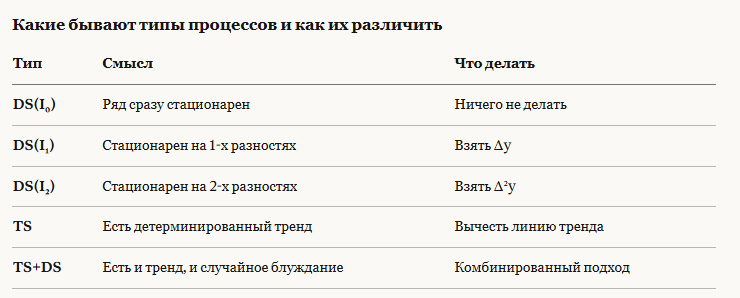